In [ ]:
# Đăng ký thư viện vnstock
from vnstock import register_user
register_user()

In [1]:
import pandas as pd
# Hiển thị tối đa số dòng (không giới hạn)
pd.set_option('display.max_rows', None)
# Hiển thị full cột khi in DataFrame:
pd.set_option('display.max_columns', None)

In [ ]:
from src.data.data_fetcher import DataFetcher

# Nguồn API là VCI, lấy group cổ phiếu VN30 - Top 30 công ty có giá trị vốn hoá lớn nhất Việt Nam 
fetch_agent = DataFetcher(source='VCI')
vn30_tickers = fetch_agent.get_group_ticker("VN30")
print(vn30_tickers)

In [ ]:
# Merge fundamental dữ liệu (Income,Balance...) thành 1 bảng duy nhất
master_df = fetch_agent.get_merged_financial_reports(vn30_tickers)
master_df.info()

In [ ]:
# Lấy dữ liệu stock của các mã tại các ngày công bố báo cáo tài chính
df_with_price = fetch_agent.align_and_fetch_price(master_df, align_quarter_dates=True)
# Chạy tính Return cho FinRL
df_finrl = fetch_agent.calculate_y_return(df_with_price)
# Kiểm tra thử kết quả
df_finrl[['ticker', 'yearReport', 'lengthReport', 'Quarter_Time', 'actual_price_date', 'adj_close_q', 'y_return']]

In [ ]:
import os
#Lưu lại dữ liệu vào file csv để tránh khi chạy lại fetch API, dùng tài khoản thường bị hạn chế
file_name = "raw_fundamental_data.csv"
# Kiểm tra nếu file tồn tại thì xoá
if os.path.exists(file_name):
    os.remove(file_name)
    print(f"Đã xoá file cũ: {file_name}")
# Lưu lại file mới
df_finrl.to_csv(file_name, index=False)
print(f"Đã lưu file mới: {file_name}")

In [2]:
df_finrl = pd.read_csv("raw_fundamental_data.csv")
df_finrl.head(5)

,ticker,yearReport,lengthReport,TOTAL ASSETS (Bn. VND),Cash and cash equivalents (Bn. VND),Balances with the SBV,Placements with and loans to other credit institutions,"Trading Securities, net",Trading Securities,Provision for diminution in value of Trading Securities,Derivatives and other financial liabilities,"Loans and advances to customers, net",Loans and advances to customers,Less: Provision for losses on loans and advances to customers,Investment Securities,Available-for Sales Securities,Held-to-Maturity Securities,Less: Provision for diminution in value of investment securities,Long-term investments (Bn. VND),Investments in associate companies,Other long-term assets (Bn. VND),Less: Provision for diminuation in value of long term investments,Fixed assets (Bn. VND),Tangible fixed assets,Intagible fixed assets,Investment in properties,Other Assets,TOTAL RESOURCES (Bn. VND),LIABILITIES (Bn. VND),Due to Gov and borrowings from SBV,Deposits and borrowings from other credit institutions,Deposits from customers,_Derivatives and other financial liabilities,"Funds received from Gov, international and other institutions",Convertible bonds/CDs and other valuable papers issued,Other liabilities,OWNER'S EQUITY(Bn.VND),Capital,Reserves,Foreign Currency Difference reserve,Undistributed earnings (Bn. VND),Paid-in capital (Bn. VND),MINORITY INTERESTS,Revenue (Bn. VND),Revenue YoY (%),Attribute to parent company (Bn. VND),Attribute to parent company YoY (%),Interest and Similar Income,Interest and Similar Expenses,Net Interest Income,Fees and Comission Income,Fees and Comission Expenses,Net Fee and Commission Income,Net gain (loss) from foreign currency and gold dealings,Net gain (loss) from trading of trading securities,Net gain (loss) from disposal of investment securities,Net Other income/(expenses),Other expenses,Net Other income/expenses,Dividends received,Total operating revenue,General & Admin Expenses,Operating Profit before Provision,Provision for credit losses,Profit before tax,Tax For the Year,Business income tax - current,Business income tax - deferred,Net Profit For the Year,Attributable to parent company,EPS_basis,Profits from other activities,Operating profit before changes in working capital,Net Cash Flows from Operating Activities before BIT,Payment from reserves,Purchase of fixed assets,Gain on Dividend,Net Cash Flows from Investing Activities,Increase in charter captial,Cash flows from financial activities,Net increase/decrease in cash and cash equivalents,Cash and cash equivalents,Foreign exchange differences Adjustment,Cash and Cash Equivalents at the end of period,Net cash inflows/outflows from operating activities,Proceeds from disposal of fixed assets,Investment in other entities,Proceeds from divestment in other entities,Dividends paid,Debt/Equity,Fixed Asset-To-Equity,Owners' Equity/Charter Capital,Net Profit Margin (%),ROE (%),ROIC (%),ROA (%),Dividend yield (%),Financial Leverage,Market Capital (Bn. VND),Outstanding Share (Mil. Shares),P/E,P/B,P/S,P/Cash Flow,EPS (VND),BVPS (VND),Quarter_Time,Investment in joint ventures,Leased assets,Difference upon Assets Revaluation,Minority Interest,Other Reserves,CURRENT ASSETS (Bn. VND),Short-term investments (Bn. VND),Accounts receivable (Bn. VND),Net Inventories,Other current assets,LONG-TERM ASSETS (Bn. VND),Other non-current assets,Current liabilities (Bn. VND),Long-term liabilities (Bn. VND),Capital and reserves (Bn. VND),Prepayments to suppliers (Bn. VND),Short-term loans receivables (Bn. VND),"Inventories, Net (Bn. VND)",Other current assets (Bn. VND),Investment and development funds (Bn. VND),Common shares (Bn. VND),Advances from customers (Bn. VND),Short-term borrowings (Bn. VND),Good will (Bn. VND),Long-term prepayments (Bn. VND),Other long-term receivables (Bn. VND),Long-term trade receivables (Bn. VND),Financial Income,Interest Expenses,Sales,Sales deductions,Net Sales,Cost of Sales,Gross Profit,Financial Expenses,Gain/(loss) from joint ventures,Selling Expens

In [3]:
# Loại bỏ mã cổ phiếu VPL bởi vì bị huy niêm yết nên không đủ dữ liệu tài chính các quarter
df_finrl = df_finrl[df_finrl['ticker'] != 'VPL'].copy()

In [4]:
from src.data.data_process import DataProcess
#Feature Engineering - lấy các chỉ số quan trọng trong các báo cáo 
processor = DataProcess(df_finrl)
clean_dataset = processor.extract_features()
clean_dataset.head()

Đã khởi tạo DataProcess. Chuẩn bị Feature Engineering...
✅ Engineering 14 Features thành công! Dữ liệu đạt 580 dòng và 19 cột chuẩn bị châm vào Model.


,ticker,Quarter_Time,yearReport,lengthReport,EPS,BPS,DPS,cur_ratio,quick_ratio,cash_ratio,acc_rec_turnover,debt_ratio,debt_to_equity,pe,ps,pb,roe,net_income_ratio,y_return
0,ACB,2021-03-31,2021,1,919.114998,14037.773468,0.0,0.0,0.0,0.0,0.0,0.915622,10.851374,10.254612,4.547574,2.332991,0.251710,0.535265,-0.051293
1,ACB,2021-06-30,2021,2,957.914411,14944.863439,0.0,0.0,0.0,0.0,0.0,0.914317,10.670941,9.084754,4.081043,2.181351,0.264411,0.518644,0.045581
2,ACB,2021-09-30,2021,3,778.184829,15723.261447,0.0,0.0,0.0,0.0,0.0,0.911365,10.282250,9.114127,3.889029,2.086081,0.248943,0.465128,-0.003188
3,ACB,2021-12-31,2021,4,898.794104,16617.976273,0.0,0.0,0.0,0.0,0.0,0.914923,10.754104,8.694409,3.543125,1.859432,0.239026,0.506536,-0.070773
4,ACB,2022-03-31,2022,1,973.382140,14272.171532,0.0,0.0,0.0,0.0,0.0,0.908816,9.966802,7.788928,3.276627,1.681594,0.236563,0.604252,-0.015890


In [5]:
# Kiểm tra null cho tập dữ liệu 
# Đếm số lượng giá trị bằng 0.0 cho mỗi cột
zero_counts = (clean_dataset == 0.0).sum()

# Hiển thị các cột có ít nhất một giá trị 0.0 (để danh sách gọn hơn)
print("Số lượng giá trị 0.0 trong từng cột:")
print(zero_counts[zero_counts > 0].to_string())

# Nếu muốn xem tỷ lệ % giá trị 0.0 trên tổng số dòng
zero_ratio = (clean_dataset == 0.0).mean() * 100
print("\nTỷ lệ % giá trị 0.0:")
print(zero_ratio[zero_ratio > 0].to_string())

Số lượng giá trị 0.0 trong từng cột:
DPS                 519
cur_ratio           280
quick_ratio         280
cash_ratio          280
acc_rec_turnover    300
y_return              4

Tỷ lệ % giá trị 0.0:
DPS                 89.482759
cur_ratio           48.275862
quick_ratio         48.275862
cash_ratio          48.275862
acc_rec_turnover    51.724138
y_return             0.689655


## Tại sao lại xuất hiện giá trị null
1. Hiện tượng "Nhóm các ngân hàng" (296 - 310 dòng bị 0.0)
cur_ratio (296), quick_ratio (296), cash_ratio (296), acc_rec_turnover (310): Rất dễ thấy con số xấp xỉ 300 dòng này chính là đại diện cho nhóm Ngân hàng (Ví dụ VCB, BID, CTG, TCB, MBB...).
Lý do: Các ngân hàng thương mại đặc thù kinh doanh tiền, họ KHÔNG dùng khái niệm "Tài sản ngắn hạn" (Current Assets), "Hàng tồn kho" (Inventory) hay "Khoản phải thu" (Accounts Receivable) giống như Hòa Phát (HPG) hay Vinamilk (VNM). Do đó, dữ liệu trả về rỗng và tự động lấp bằng 0. (Gồm khoảng 14 ngân hàng trong VN30 $\times$ 20 quý = ~280 - 300 dòng).

2. Hiện tượng "Cổ tức" (DPS - 536 dòng bị 0.0)
Trong rổ VN30, lượng công ty chi trả cổ tức bằng tiền mặt đều đặn qua mỗi quý là cực kỳ hiếm. Họ thường trả 1 năm/lần hoặc trả bằng cổ phiếu. Nên việc phần lớn các quý công ty không có Cổ tức (Cột DPS = 0) là dữ kiện thực tế và hoàn toàn chính xác.

3. Số lượng nhỏ lạc tẻ (EPS, P/E, P/S, P/B từ 3 - 16 dòng)
Đây là những quý sơ khai lúc công ty mới lên sàn, hoặc những quý API bị khuyết biểu đồ định giá. Code của mình đã dùng Forward Fill để mượn quý trước đắp lên, tuy nhiên nếu Quý đầu tiên (chưa có quá khứ để mượn) bị rỗng thì nó buộc phải chốt chặn bằng mức 0.0 để bảo vệ Model không bị văng lỗi.

4. Đối với nhãn huấn luyện: y_return (19 dòng bị 0)
Một giá trị Log Return = 0 chỉ đơn giản là Quý kế tiếp giá cổ phiếu đóng cửa y chang như giá quý này, không dao động (Đi ngang hoàn toàn). Model sẽ học được là với mô hình tài chính như thế thì giá trị cổ tức sinh lợi đi ngang.

## Huấn luyện Mô Hình

In [6]:
from src.strategies.ml_strategy import EnsembleMLStrategy

# Define feature and targe before training model

features = [
    'EPS', 'BPS', 'DPS', 'cur_ratio', 'quick_ratio', 'cash_ratio',
    'acc_rec_turnover', 'debt_ratio', 'debt_to_equity',
    'pe', 'ps', 'pb', 'roe', 'net_income_ratio'
]

target = 'y_return'

# Init training model

ml_test = EnsembleMLStrategy(
    df=clean_dataset,
    features=features,
    target=target,
    train_window_quarters=12
)

# Run and check model performance
ranking, train_models = ml_test.walk_forward_competition()

print("\nModel Top 1 đã chốt:", list(ranking.keys())[0])

Đang tiền xử lý Dữ liệu Chuỗi Thời Gian (Time-Series)...

 Test MODEL (Walk-Forward Rolling Window: 12 Quý Train -> 1 Quý Test)
------------------------------------------------------------
BƯỚC 1/6 | Huấn luyện Quý Test: 2024Q1 | Size: Train(348), Test(29)
BƯỚC 2/6 | Huấn luyện Quý Test: 2024Q2 | Size: Train(348), Test(29)
BƯỚC 3/6 | Huấn luyện Quý Test: 2024Q3 | Size: Train(348), Test(29)
BƯỚC 4/6 | Huấn luyện Quý Test: 2024Q4 | Size: Train(348), Test(29)
BƯỚC 5/6 | Huấn luyện Quý Test: 2025Q1 | Size: Train(348), Test(29)
BƯỚC 6/6 | Huấn luyện Quý Test: 2025Q2 | Size: Train(348), Test(29)

🏆 KẾT QUẢ KIỂM THỬ TỪNG MÔ HÌNH (Trung bình lỗi MSE trên tất cả các Quý Test)
------------------------------------------------------------
Mô hình: Gradient Boosting    | Lỗi MSE trung bình: 0.029930
Mô hình: Random Forest        | Lỗi MSE trung bình: 0.032365
Mô hình: XGBoost              | Lỗi MSE trung bình: 0.033886
Mô hình: LightGBM             | Lỗi MSE trung bình: 0.035435

Model Top 1 đã chố

In [ ]:
ml_test.plot_model_comparison(ranking)

In [ ]:
# Điền mã bạn muốn săm soi vào đây (Ví dụ HPG, FPT, VCB)
ticker_kiem_tra = "FPT"

# Lên biểu đồ và lấy DataFrame
df_so_sanh = ml_test.analyze_ticker(ticker_kiem_tra)

# In ra bảng đối chiếu chi tiết các con số (Dùng hiển thị bằng Pandas)
display(df_so_sanh)

## Run backtest

In [7]:
from src.backtest.backtest_engine import BacktestEngine

# 1. Thu thập Tỷ trọng Đầu tư (Dùng kết quả của Model)
weights_matrix = ml_test.generate_weights_matrix(top_k=5, chosen_model='Gradient Boosting')

📦 **Vnstock 3.5.0 is available**
Current version: 3.4.2
Update: `pip install vnstock --upgrade`
Release history: https://vnstocks.com/docs/tai-lieu/lich-su-phien-ban

📦 **Vnai 2.4.0 is available**
Current version: 2.3.9
Update: `pip install vnai --upgrade`
Release history: https://pypi.org/project/vnai/#history

In [8]:
weights_matrix

,GVR,FPT,DGC,VNM,VCB,VHM,VIB,TCB,VIC,ACB,STB,MWG,VJC,SHB,LPB,TPB
Date,,,,,,,,,,,,,,,,
2024-03-31,0.2,0.2,0.2,0.2,0.2,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0
2024-06-30,0.2,0.2,0.0,0.0,0.0,0.2,0.2,0.2,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0
2024-09-30,0.0,0.2,0.0,0.0,0.0,0.0,0.0,0.2,0.2,0.2,0.2,0.0,0.0,0.0,0.0,0.0
2024-12-31,0.0,0.0,0.0,0.0,0.2,0.2,0.0,0.0,0.2,0.2,0.0,0.2,0.0,0.0,0.0,0.0
2025-03-31,0.0,0.0,0.0,0.0,0.0,0.2,0.0,0.0,0.2,0.0,0.0,0.0,0.2,0.2,0.2,0.0
2025-06-30,0.0,0.0,0.0,0.0,0.0,0.2,0.0,0.0,0.0,0.0,0.0,0.2,0.2,0.2,0.0,0.2


Đang gọi API VNStock tải Giá Hàng Ngày từ 2024-03-31 đến 2025-09-30...


✅ Tải Giá VNStock Thành Công!

Đang khởi chiếu Sàn Đấu Backtest (Simulation)...


100%|██████████| 1/1 [00:00<00:00,  7.07it/s]


=== MÔ PHỎNG BACKTEST HOÀN TẤT ===
Stat                 AI_Quantitative_Fund
-------------------  ----------------------
Start                2024-03-03
End                  2025-09-30
Risk-free rate       0.00%

Total Return         103.74%
Daily Sharpe         2.49
Daily Sortino        4.04
CAGR                 57.03%
Max Drawdown         -9.77%
Calmar Ratio         5.84

MTD                  -6.89%
3m                   37.59%
6m                   69.27%
YTD                  94.87%
1Y                   103.74%
3Y (ann.)            -
5Y (ann.)            -
10Y (ann.)           -
Since Incep. (ann.)  57.03%

Daily Sharpe         2.49
Daily Sortino        4.04
Daily Mean (ann.)    47.37%
Daily Vol (ann.)     19.03%
Daily Skew           -0.04
Daily Kurt           9.60
Best Day             6.82%
Worst Day            -6.85%

Monthly Sharpe       1.75
Monthly Sortino      9.12
Monthly Mean (ann.)  52.20%
Monthly Vol (ann.)   29.83%
Monthly Skew         1.27
Monthly Kurt         0.35
Best M

<Figure size 1200x600 with 0 Axes>

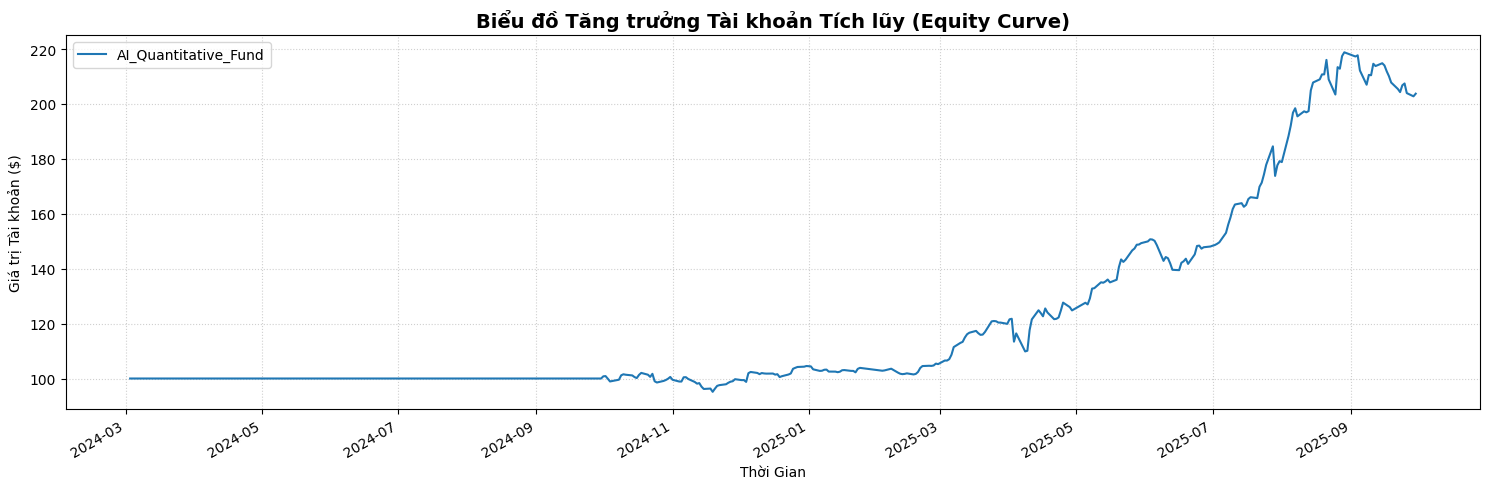

In [9]:
# 2. Đưa Tỷ trọng vào Backtest (Cấp Vốn 10,000 USD)
engine = BacktestEngine(weights_df=weights_matrix, initial_capital=10000)
# 3. Phóng Mô phỏng (Vắt kiệt lịch sử)
engine.run_simulation()
# 4. Trích xuất Bảng Điểm KPIs & Bản đồ Biến Động Vốn
engine.report_kpis()